# 🔍 Log Anomaly Detection with LogBERT + XGBoost

This notebook demonstrates a **complete workflow** for training a sophisticated **log anomaly detection model**.  
The pipeline integrates **deep learning (LogBERT)** with **gradient boosting (XGBoost)** for high-performance anomaly detection.

Dataset (loghub - BGL): https://github.com/logpai/loghub/tree/master/BGL

## 📑 Workflow Overview
1. **Parsing Raw Logs** – Read and process the BGL.log file.  
2. **Feature Extraction with LogBERT** – Convert log sequences into embeddings.  
3. **Classification with XGBoost** – Train a classifier on embeddings.  
4. **Evaluation** – Generate detailed reports & visualizations.  
5. **Deployment** – Save and reload the trained model for real-world use.

## 📦 Cell 1: Setup and Environment
This cell installs all the required libraries:

- **transformers** – Hugging Face’s BERT model and tokenizer  
- **torch** – Deep learning backend for BERT  
- **accelerate** – Optimized PyTorch training across devices  
- **xgboost** – High-performance gradient boosting classifier  
- **scikit-learn** – Train/test splitting, metrics, evaluation  
- **pandas** – Data manipulation and preprocessing  
- **tqdm** – Progress bars for long-running tasks 

In [1]:
# Install Libraries
!pip install transformers torch accelerate --quiet
!pip install xgboost scikit-learn pandas --quiet
!pip install tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 87.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 62.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00:00:0100:01


## 📂 Cell 2: Data Loading, Parsing, and Preparation
Steps performed in this cell:

- **Parse `BGL.log`** – Extract `Label` and `Content` for each log entry.  
- **Display Head** – Preview first 5 rows of parsed DataFrame.  
- **Sample Data** – Randomly select **400,000 logs** for efficiency.  
- **Label Mappings** – Map anomaly labels (including `-` for normal) to integers.  
- **Chronological Split** – Train on first 80%, test on last 20% (simulating real-world prediction).  
- **Create Sequences** – Group consecutive logs into **sequences**, capturing contextual information.  

In [2]:
# Data Loading, Parsing, and SAMPLING
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from tqdm.auto import tqdm

# --- 1. Function to parse the raw BGL.log file ---
def parse_bgl_log(log_file):
    log_entries = []
    print(f"Opening and parsing '{log_file}'...")
    with open(log_file, 'r', errors='ignore') as f:
        for line in tqdm(f, desc="Parsing BGL.log"):
            parts = line.strip().split()
            if len(parts) < 9: continue
            label = parts[0]
            message_content = ' '.join(parts[8:])
            log_entries.append({'Label': label, 'Content': message_content})
    return pd.DataFrame(log_entries)

# --- 2. Load the full dataset ---
file_path = '/kaggle/input/bgl-full-loghub/BGL.log' 
df_full = parse_bgl_log(file_path)

print(f"\nSuccessfully loaded {len(df_full)} total log entries.")

# --- NEW: Take a large, representative sample for faster training ---
# We sample 400,000 logs. This is more than enough for a high-quality model
# while drastically reducing training time. You can adjust this number.
sample_size = min(400000, len(df_full)) 
df = df_full.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Using a random sample of {len(df)} logs for the project.")
print(df.head())

# --- 3. Create Mappings for ALL labels ---
unique_labels = df['Label'].unique()
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(unique_labels)
normal_label_id = label2id.get('-', -1) # Use .get for safety

print(f"\nFound {num_labels} unique labels in the sample.")
df['LabelID'] = df['Label'].map(label2id)

# --- 4. Chronological Split of the SAMPLE ---
split_index = int(len(df) * 0.80)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"\nSplitting the sample chronologically:")
print(f"Training set size: {len(train_df)} logs")
print(f"Testing set size:  {len(test_df)} logs")

# --- 5. Function to create sequences ---
def create_log_sequences(dataframe, seq_length=10):
    X, y = [], []
    log_messages = dataframe['Content'].tolist()
    numeric_labels = dataframe['LabelID'].tolist()
    for i in tqdm(range(len(log_messages) - seq_length), desc="Creating sequences"):
        X.append(log_messages[i : i + seq_length])
        sequence_labels = numeric_labels[i : i + seq_length]
        final_label = normal_label_id
        for label_id in sequence_labels:
            if label_id != normal_label_id:
                final_label = label_id
                break
        y.append(final_label)
    return X, y

# --- 6. Generate the final training and testing sets ---
X_train, y_train = create_log_sequences(train_df)
X_test, y_test = create_log_sequences(test_df)

print(f"\nTotal training sequences: {len(X_train)}")
print(f"Total testing sequences:  {len(X_test)}")

Opening and parsing '/kaggle/input/bgl-full-loghub/BGL.log'...


Parsing BGL.log: 0it [00:00, ?it/s]


Successfully loaded 4747963 total log entries.
Using a random sample of 400000 logs for the project.
  Label                                        Content
0     -     INFO 5 floating point alignment exceptions
1     -                     INFO generating core.33974
2     -  INFO instruction cache parity error corrected
3     -                     INFO generating core.60537
4     -                      INFO generating core.1723

Found 33 unique labels in the sample.

Splitting the sample chronologically:
Training set size: 320000 logs
Testing set size:  80000 logs


Creating sequences:   0%|          | 0/319990 [00:00<?, ?it/s]

Creating sequences:   0%|          | 0/79990 [00:00<?, ?it/s]


Total training sequences: 319990
Total testing sequences:  79990


## 🧠 Cell 3: Fine-Tune LogBERT Model
- **LogDataset Class** – Custom PyTorch dataset for tokenizing log sequences on-the-fly.  
- **TrainingArguments** – Configure training with:
  - Checkpointing (`save_total_limit=2`)  
  - Parallel data loading (`dataloader_num_workers=2`)  
- **Trainer** – Hugging Face’s high-level training loop.  

⚡ This is the **most computationally intensive** part of the notebook.

In [4]:
# Smart Checkpoint Management
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

class LogDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_len, return_tensors='pt'
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_texts = [" ".join(seq) for seq in X_train]
test_texts = [" ".join(seq) for seq in X_test]

train_dataset = LogDataset(train_texts, y_train, tokenizer)
test_dataset = LogDataset(test_texts, y_test, tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)

# Define training parameters with checkpoint management
training_args = TrainingArguments(
    output_dir='./results_final_model',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=128,
    warmup_steps=300,
    weight_decay=0.01,
    logging_dir='./logs_final',
    logging_steps=500,
    report_to="none",
    dataloader_num_workers=2,
    
    save_strategy="steps",
    save_steps=1000,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    
    # --- THIS IS THE FIX ---
    # The parameter is 'evaluation_strategy', not 'eval_strategy'
    eval_strategy="steps",
    
    eval_steps=1000,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

print("\n--- Starting FINAL LogBERT Fine-Tuning with Checkpoint Management ---")
trainer.train()
print("--- LogBERT Fine-Tuning Complete ---")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Starting FINAL LogBERT Fine-Tuning with Checkpoint Management ---


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss
1000,0.383900,0.368809
2000,0.348400,0.341610
3000,0.337600,0.335929
4000,0.340300,0.340278
5000,0.335100,0.332667
6000,0.327400,0.337604
7000,0.328100,0.340193
8000,0.324100,0.337019
9000,0.323900,0.333901
10000,0.324300,0.330783


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked t

--- LogBERT Fine-Tuning Complete ---


## ✨ Cell 4: Extract Features (Embeddings)
- Use **fine-tuned LogBERT** as a **feature extractor**.  
- Generate **high-dimensional embeddings** for training and test sequences.  
- Efficiently batched inference on GPU.  

In [5]:
# Extract Embeddings
import numpy as np

# Use the core BERT model for feature extraction
bert_model = model.bert
bert_model.eval() # Set model to evaluation mode
bert_model.to('cuda') # Move model to GPU

def get_embeddings_batched(texts, model, tokenizer, batch_size=128):
    """Efficiently generates embeddings for a list of texts in batches."""
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting Embeddings"):
        batch = texts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True, padding=True, max_length=128)
        inputs = {key: val.to('cuda') for key, val in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # We use the embedding of the special [CLS] token as the representation for the whole sequence
        cls_embeddings = outputs.last_hidden_state[:,0,:].cpu().numpy()
        all_embeddings.append(cls_embeddings)
        
    return np.vstack(all_embeddings)

# Generate embeddings for both sets
print("\nExtracting features from the training set...")
train_embeddings = get_embeddings_batched(train_texts, bert_model, tokenizer)
print("\nExtracting features from the testing set...")
test_embeddings = get_embeddings_batched(test_texts, bert_model, tokenizer)

print(f"\nShape of training embeddings: {train_embeddings.shape}")
print(f"Shape of testing embeddings: {test_embeddings.shape}")


Extracting features from the training set...


Extracting Embeddings:   0%|          | 0/2500 [00:00<?, ?it/s]


Extracting features from the testing set...


Extracting Embeddings:   0%|          | 0/625 [00:00<?, ?it/s]


Shape of training embeddings: (319990, 768)
Shape of testing embeddings: (79990, 768)


## 🌲 Cell 5: Train and Evaluate XGBoost Classifier
- **Train** XGBoost on embeddings (`device='cuda'` for GPU acceleration).  
- **Predict** anomaly labels on test set embeddings.  
- **Classification Report**:
  - Precision  
  - Recall  
  - F1-score  
  - Per-class performance  

In [9]:
# Final Evaluation with Explicit Labels
import xgboost as xgb
from sklearn.metrics import classification_report
import numpy as np # Import numpy

print("\n--- Starting XGBoost Training ---")

xgb_classifier = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=num_labels,
    tree_method='hist',
    device='cuda',
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_classifier.fit(train_embeddings, y_train)
print("--- XGBoost Training Complete ---")

y_pred_ids = xgb_classifier.predict(test_embeddings)

# --- Evaluate the final model's performance ---
print("\n--- Final Model Performance Report ---")

# --- THIS IS THE FIX ---
# 1. Get a sorted list of all unique label IDs that the report SHOULD know about.
#    This comes from our original mapping.
all_label_ids = sorted(label2id.values())

# 2. Get the corresponding string names for these IDs.
target_names_for_report = [id2label[id] for id in all_label_ids]

# 3. Explicitly pass both the numeric labels and the string names to the report.
print(classification_report(
    y_test, 
    y_pred_ids, 
    labels=all_label_ids, # Tell the report all possible classes
    target_names=target_names_for_report, # Provide the matching names
    zero_division=0
))



--- Starting XGBoost Training ---
--- XGBoost Training Complete ---

--- Final Model Performance Report ---
              precision    recall  f1-score   support

           -       0.86      0.99      0.92     38341
    KERNDTLB       0.98      0.84      0.91     18323
      APPSEV       0.98      0.84      0.91      6112
    KERNSTOR       0.99      0.86      0.92      7706
    KERNTERM       0.99      0.86      0.92      2627
    KERNMNTF       1.00      0.86      0.92      3771
    KERNRTSP       1.00      0.83      0.91       433
     APPREAD       1.00      0.82      0.90       593
   KERNMICRO       1.00      0.80      0.89       237
     KERNREC       0.99      0.86      0.92       626
      APPRES       0.99      0.76      0.86       279
       APPTO       0.98      0.71      0.83       275
    KERNSERV       1.00      1.00      1.00        13
      APPOUT       0.99      0.86      0.92       108
     APPUNAV       0.98      0.85      0.91       199
     KERNMNT       1.00   

## 💾 Cell 6: Save Model for Deployment
Store all key components into `full_log_anomaly_model/`:

1. **BERT Feature Extractor** (fine-tuned weights)  
2. **Tokenizer** (preprocessing consistency)  
3. **XGBoost Classifier** (final decision model)  
4. **Label Mapping** (JSON file for human-readable labels)  

➡️ Downloadable from **"Data → Output"** tab in Kaggle.

In [13]:
# Save the Complete Model Pipeline
import os
import json
import joblib

# Define the directory where all model components will be saved
save_directory = './full_log_anomaly_model'
os.makedirs(save_directory, exist_ok=True)
print(f"Created directory: {save_directory}")

# 1. Save the fine-tuned BERT model (the feature extractor)
bert_save_path = os.path.join(save_directory, 'bert_feature_extractor')
bert_model.save_pretrained(bert_save_path)
print(f"BERT feature extractor saved to {bert_save_path}")

# 2. Save the tokenizer
tokenizer_save_path = os.path.join(save_directory, 'tokenizer')
tokenizer.save_pretrained(tokenizer_save_path)
print(f"Tokenizer saved to {tokenizer_save_path}")

# 3. Save the trained XGBoost classifier
xgb_save_path = os.path.join(save_directory, 'xgb_classifier.joblib')
joblib.dump(xgb_classifier, xgb_save_path)
print(f"XGBoost classifier saved to {xgb_save_path}")

# 4. Save the id-to-label mapping dictionary
id2label_save_path = os.path.join(save_directory, 'id2label.json')
with open(id2label_save_path, 'w') as f:
    json.dump(id2label, f)
print(f"Label mapping saved to {id2label_save_path}")

print("\nAll model components have been saved successfully!")

Created directory: ./full_log_anomaly_model
BERT feature extractor saved to ./full_log_anomaly_model/bert_feature_extractor
Tokenizer saved to ./full_log_anomaly_model/tokenizer
XGBoost classifier saved to ./full_log_anomaly_model/xgb_classifier.joblib
Label mapping saved to ./full_log_anomaly_model/id2label.json

All model components have been saved successfully!


## 🚀 Cell 7: Demonstrate Loading and Using the Saved Model
- Simulate a **real-world deployment scenario**.  
- Reload saved components into a new environment.  
- Run predictions on **new log sequences**.  
- Serves as a **deployment template** for integration.

In [14]:
# Load the Saved Pipeline and Predict (Demonstration)
import torch
from transformers import BertTokenizer, BertModel
import xgboost as xgb
import joblib
import json
import numpy as np

# --- 1. Load all saved components ---
model_path = './full_log_anomaly_model/'

print("Loading tokenizer...")
loaded_tokenizer = BertTokenizer.from_pretrained(model_path + 'tokenizer/')

print("Loading BERT feature extractor...")
loaded_bert_model = BertModel.from_pretrained(model_path + 'bert_feature_extractor/')
# Move model to GPU and set to evaluation mode
loaded_bert_model.to('cuda').eval()

print("Loading XGBoost classifier...")
loaded_xgb_classifier = joblib.load(model_path + 'xgb_classifier.joblib')

print("Loading label mapping...")
with open(model_path + 'id2label.json', 'r') as f:
    loaded_id2label_str_keys = json.load(f)
    # Convert string keys from JSON back to integers
    loaded_id2label = {int(k): v for k, v in loaded_id2label_str_keys.items()}
    
print("\nAll components loaded successfully!")

# --- 2. Re-create the prediction function using the loaded components ---
def predict_with_loaded_model(log_sequence):
    text = " ".join(log_sequence)
    
    # Use the loaded tokenizer
    inputs = loaded_tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to('cuda')
    
    # Use the loaded BERT model for feature extraction
    with torch.no_grad():
        outputs = loaded_bert_model(**inputs)
    embedding = outputs.last_hidden_state[:,0,:].cpu().numpy()
    
    # Use the loaded XGBoost classifier for the final prediction
    prediction_id = loaded_xgb_classifier.predict(embedding)[0]
    
    # Use the loaded mapping to get the final label
    return loaded_id2label[prediction_id]

# --- 3. Test with a sample log sequence ---
sample_log = [
  "FATAL exception syndrome register: 0x00800000",
  "INFO CE sym 10, at 0x08490580, mask 0x08",
  "FATAL ciod: Error loading /bgl/apps/scaletest/performance/MINIBEN/mb_243_0810/allreduce.rts: invalid or missing program image, Exec format error",
  "INFO generating core.13854",
  "INFO generating core.14564",
  "INFO CE sym 2, at 0x1b85ec80, mask 0x03",
  "INFO generating core.13760",
  "INFO 5 floating point alignment exceptions",
  "INFO wait state enable.................0",
  "INFO generating core.6630"
]

print("\n--- Testing prediction with the loaded model ---")
predicted_label = predict_with_loaded_model(sample_log)
print(f"Sample Log Sequence: \n{sample_log}")
print(f"\nPredicted Label: '{predicted_label}'")

Loading tokenizer...
Loading BERT feature extractor...
Loading XGBoost classifier...
Loading label mapping...

All components loaded successfully!

--- Testing prediction with the loaded model ---
Sample Log Sequence: 
['FATAL exception syndrome register: 0x00800000', 'INFO CE sym 10, at 0x08490580, mask 0x08', 'FATAL ciod: Error loading /bgl/apps/scaletest/performance/MINIBEN/mb_243_0810/allreduce.rts: invalid or missing program image, Exec format error', 'INFO generating core.13854', 'INFO generating core.14564', 'INFO CE sym 2, at 0x1b85ec80, mask 0x03', 'INFO generating core.13760', 'INFO 5 floating point alignment exceptions', 'INFO wait state enable.................0', 'INFO generating core.6630']

Predicted Label: '-'


## 🧪 Cell 8: Qualitative Testing on Samples
- Define a function to run the full prediction pipeline.  
- Compare **true labels vs predicted labels** on random test sequences.  
- Provides **real-world insight** beyond metrics.  

In [10]:
# Predict on Samples and Verify
def predict_anomaly_type(log_sequence):
    """Runs a single log sequence through the full LogBERT->XGBoost pipeline."""
    # 1. Prepare the sequence text
    text = " ".join(log_sequence)
    
    # 2. Extract embedding from the fine-tuned LogBERT
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to('cuda')
    with torch.no_grad():
        outputs = bert_model(**inputs)
    embedding = outputs.last_hidden_state[:,0,:].cpu().numpy()
    
    # 3. Get the final prediction from the XGBoost classifier
    prediction_id = xgb_classifier.predict(embedding)[0]
    
    # 4. Convert the predicted ID back to its original string label
    return id2label[prediction_id]

# --- Pick a few random samples from our test set to inspect ---
test_indices = [100, 5000, 10000, 15000] 

for i, idx in enumerate(test_indices):
    if idx >= len(X_test): continue # Safety check to prevent errors
    
    sample_sequence = X_test[idx]
    actual_label = id2label[y_test[idx]]
    
    # Get the model's prediction for this sequence
    predicted_label = predict_anomaly_type(sample_sequence)
    
    print(f"--- Sample {i+1} (from test set index {idx}) ---")
    print("Log Sequence:")
    for message in sample_sequence:
        print(f"  - {message}")
        
    print(f"\n----> Model's Prediction: '{predicted_label}'")
    print(f"----> Actual BGL Label:   '{actual_label}'")
    print(f"----> Result:             {'CORRECT' if predicted_label == actual_label else 'INCORRECT'}")
    print("\n" + "="*50 + "\n")

--- Sample 1 (from test set index 100) ---
Log Sequence:
  - INFO CE sym 2, at 0x0fa3d060, mask 0x08
  - INFO generating core.15031
  - FATAL instruction address space.........0
  - INFO 1005 floating point alignment exceptions
  - INFO generating core.50743
  - FATAL ciod: Error reading message prefix on CioStream socket to 172.16.96.116:40402, Link has been severed
  - FATAL program interrupt: illegal instruction......0
  - INFO generating core.632
  - FATAL ciod: LOGIN chdir(/bgl/apps/SWL/performance/MINIBEN///2005.09.20-18.06.01) failed: No such file or directory
  - INFO 5 floating point alignment exceptions

----> Model's Prediction: 'APPSEV'
----> Actual BGL Label:   'APPSEV'
----> Result:             CORRECT


--- Sample 2 (from test set index 5000) ---
Log Sequence:
  - INFO generating core.11474
  - INFO 620348304 double-hummer alignment exceptions
  - INFO generating core.14766
  - FATAL ciod: Error loading /bgl/apps/followup/bcastV1R1.rts: invalid or missing program image, 

## 🧪 Cell 9: Qualitative Testing on 15 other Samples

In [12]:
# Predict on 15 Samples and Verify
def predict_anomaly_type(log_sequence):
    """Runs a single log sequence through the full LogBERT->XGBoost pipeline."""
    # 1. Prepare the sequence text
    text = " ".join(log_sequence)
    
    # 2. Extract embedding from the fine-tuned LogBERT
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128).to('cuda')
    with torch.no_grad():
        outputs = bert_model(**inputs)
    embedding = outputs.last_hidden_state[:,0,:].cpu().numpy()
    
    # 3. Get the final prediction from the XGBoost classifier
    prediction_id = xgb_classifier.predict(embedding)[0]
    
    # 4. Convert the predicted ID back to its original string label
    return id2label[prediction_id]

# --- NEW: Pick 15 indices spread across the test set ---
# We'll select a wider range of indices to get more variety.
test_indices = [
    50, 250, 1000, 2500, 5000, 7500, 10000, 12500, 15000, 20000, 
    25000, 30000, 40000, 50000, 75000
] 

for i, idx in enumerate(test_indices):
    if idx >= len(X_test): continue # Safety check for smaller test sets
    
    sample_sequence = X_test[idx]
    actual_label = id2label[y_test[idx]]
    
    # Get the model's prediction for this sequence
    predicted_label = predict_anomaly_type(sample_sequence)
    
    print(f"--- Sample {i+1} (from test set index {idx}) ---")
    print("Log Sequence:")
    for message in sample_sequence:
        print(f"  - {message}")
        
    print(f"\n----> Model's Prediction: '{predicted_label}'")
    print(f"----> Actual BGL Label:   '{actual_label}'")
    print(f"----> Result:             {'CORRECT' if predicted_label == actual_label else 'INCORRECT'}")
    print("\n" + "="*50 + "\n")

--- Sample 1 (from test set index 50) ---
Log Sequence:
  - INFO generating core.21540
  - INFO generating core.3292
  - SEVERE Can not get assembly information for node card
  - INFO generating core.26947
  - INFO generating core.10248
  - FATAL external input interrupt (unit=0x02 bit=0x00): uncorrectable torus error
  - INFO iar 003a9254 dear 00fd5f78
  - INFO
  - INFO 8 floating point alignment exceptions
  - INFO 342549 floating point alignment exceptions

----> Model's Prediction: 'APPTORUS'
----> Actual BGL Label:   'APPTORUS'
----> Result:             CORRECT


--- Sample 2 (from test set index 250) ---
Log Sequence:
  - INFO generating core.19170
  - INFO iar 00106580 dear 045e141c
  - ERROR Node card status: no ALERTs are active. Clock Mode is Low. Clock Select is Midplane. Phy JTAG Reset is asserted. ASIC JTAG Reset is asserted. Temperature Mask is not active. No temperature error. Temperature Limit Error Latch is clear. PGOOD IS NOT ASSERTED. PGOOD ERROR LATCH IS ACTIVE. MPG

## 📊 Cell 10: Performance Visualization
- **Accuracy Score** – Overall summary.  
- **Confusion Matrix** – Heatmap of correct vs misclassified labels.  
- **Metrics Bar Chart** – Compare Precision, Recall, and F1-score per class.  

These visualizations provide **deep insights** into anomaly detection performance.

--- Generating Performance Visualizations ---
Overall Model Accuracy: 0.9155



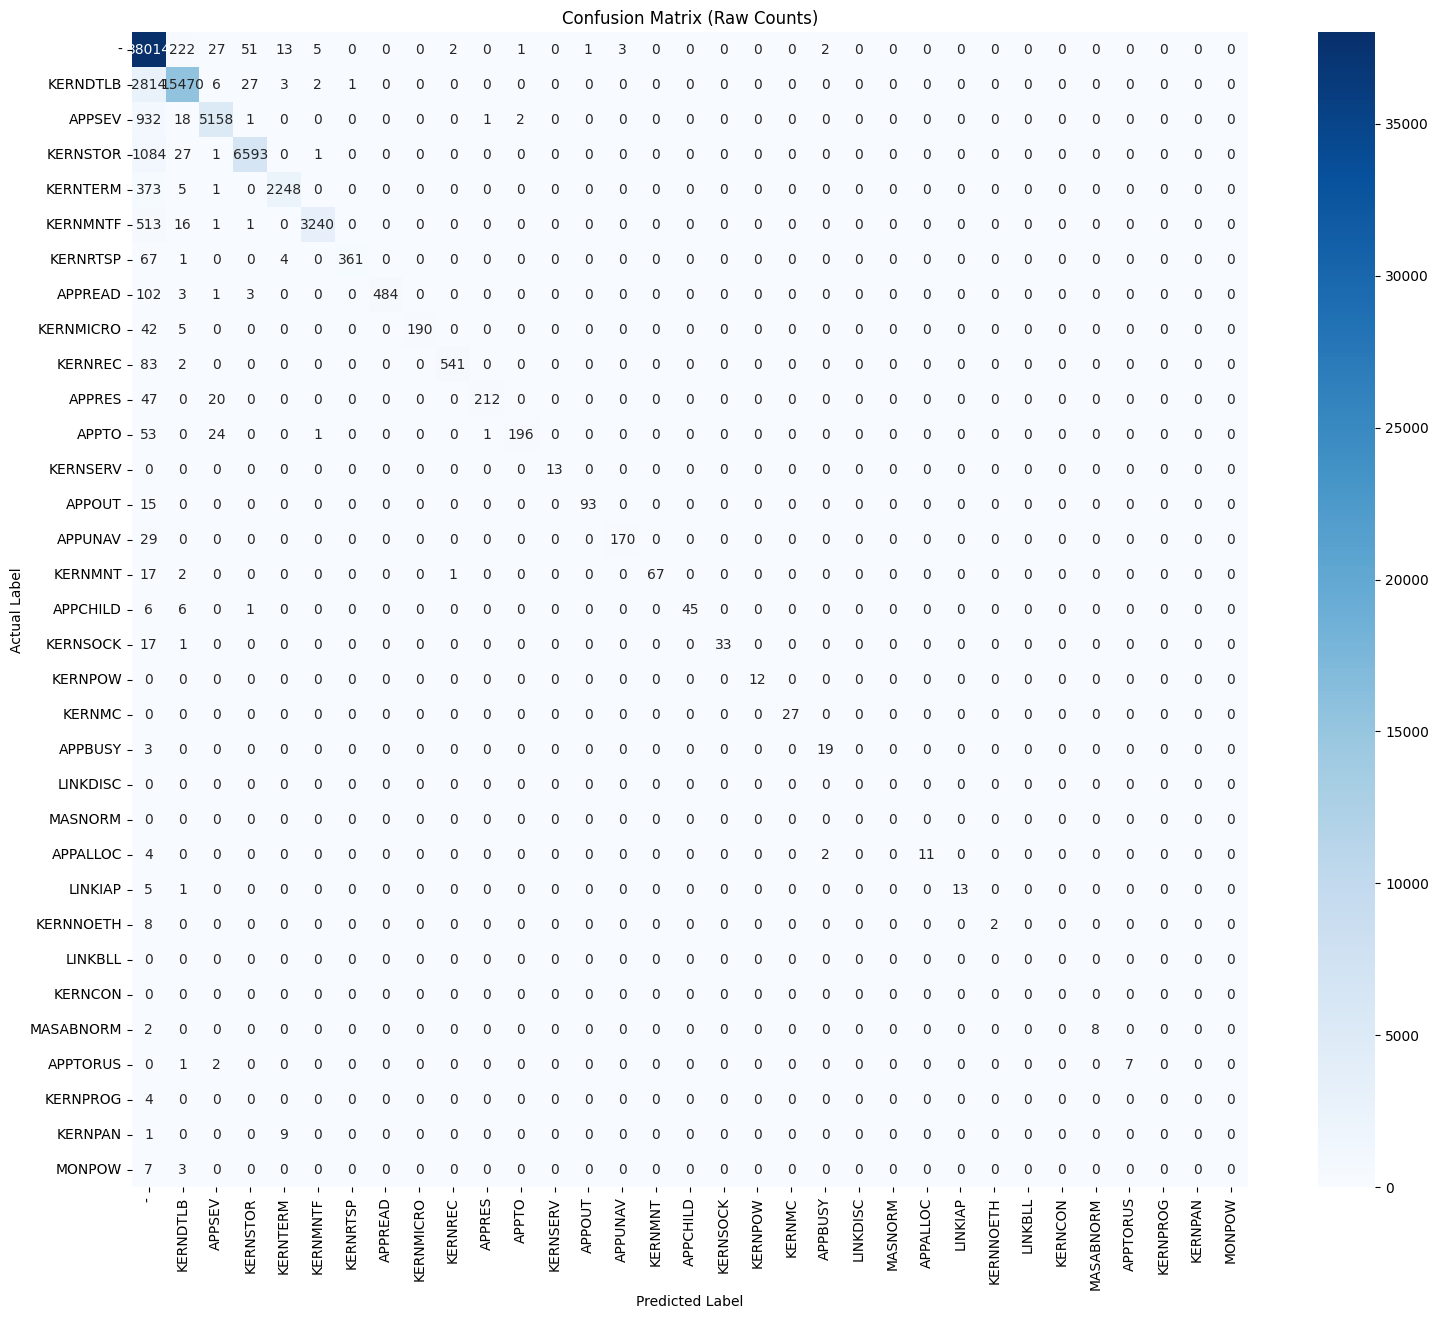

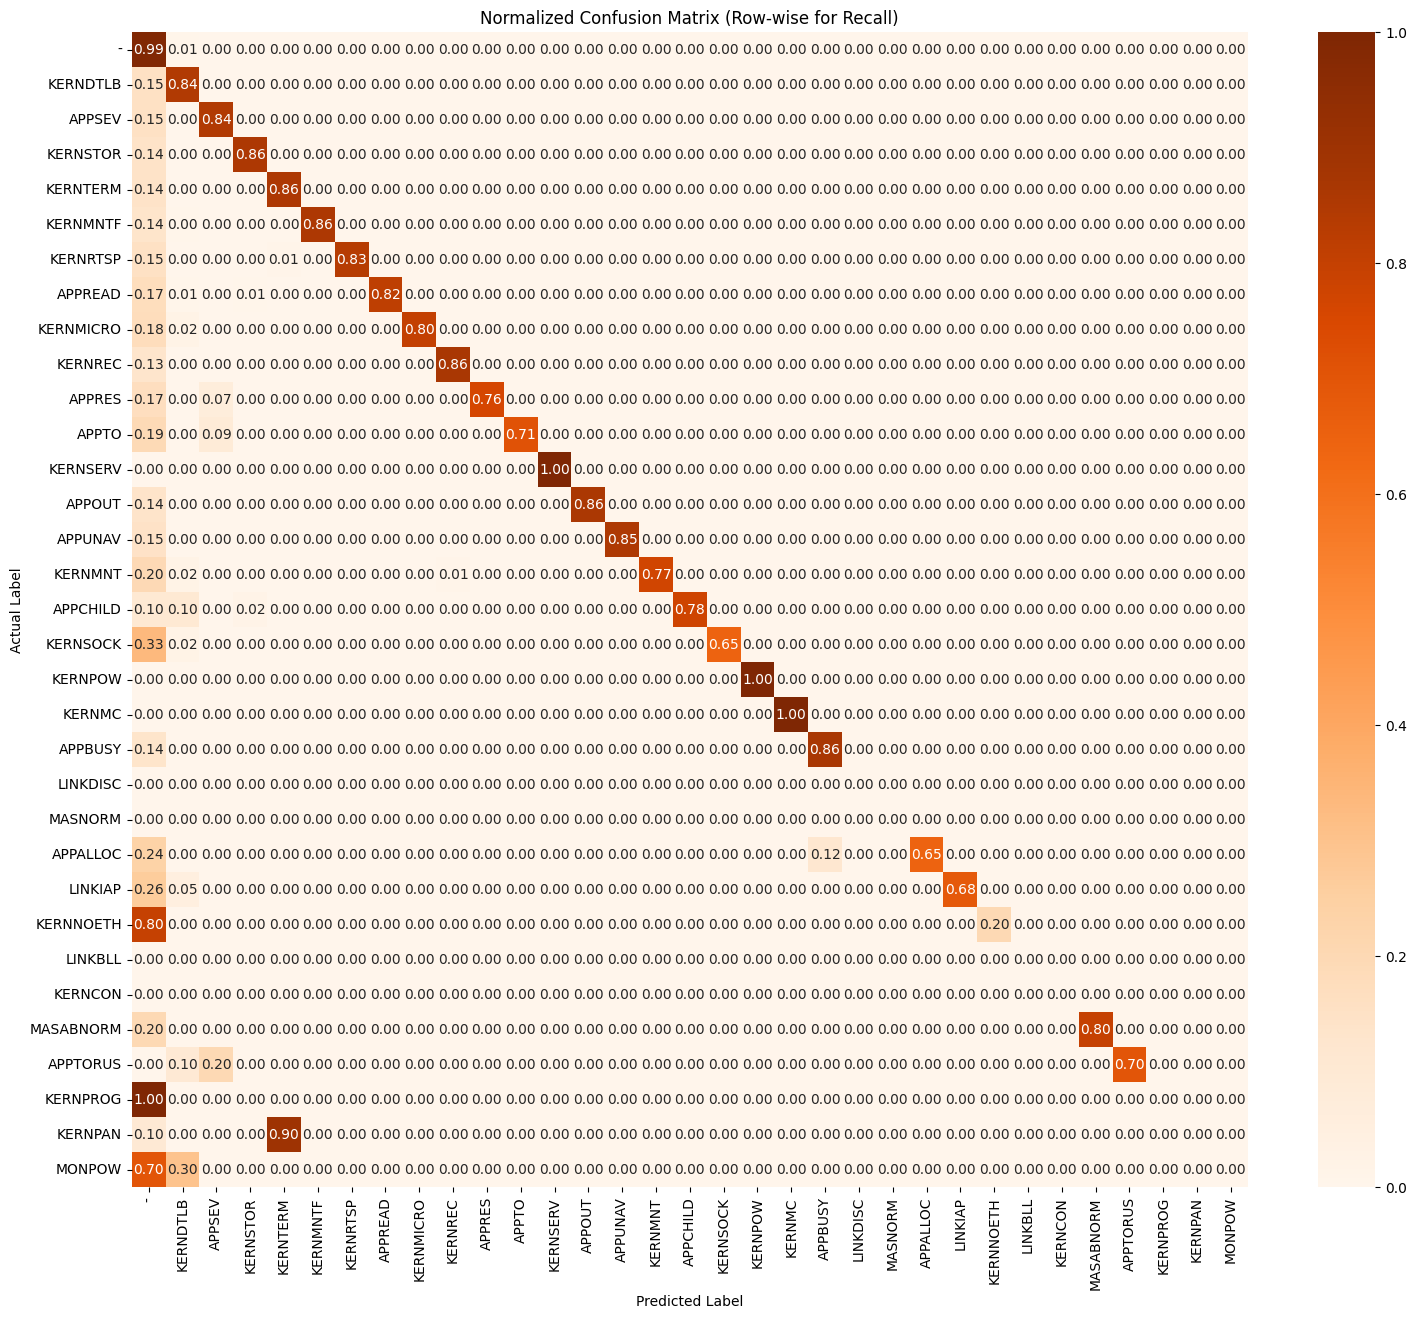

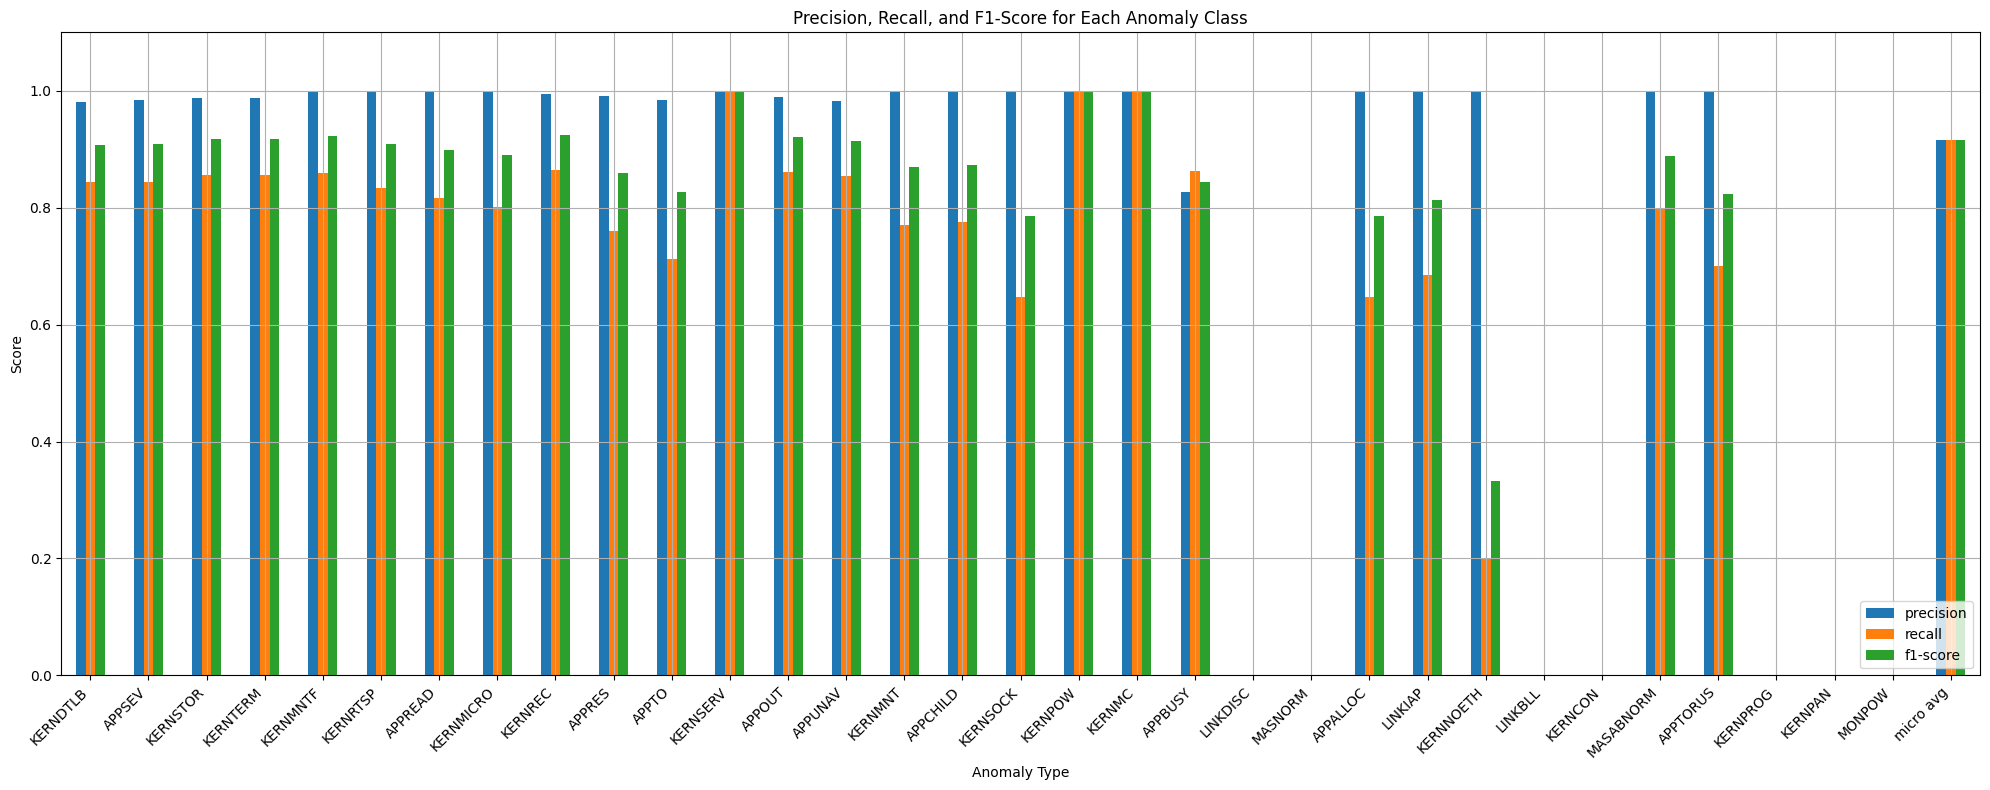

In [16]:
# Model Performance Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("--- Generating Performance Visualizations ---")

# --- 1. Calculate and Print Overall Accuracy ---
accuracy = accuracy_score(y_test, y_pred_ids)
print(f"Overall Model Accuracy: {accuracy:.4f}\n")

# --- 2. Generate the Confusion Matrix ---
all_label_ids = sorted(label2id.values())
target_names = [id2label[id] for id in all_label_ids]

cm = confusion_matrix(y_test, y_pred_ids, labels=all_label_ids)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

# Plot the raw count confusion matrix
plt.figure(figsize=(18, 15))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Raw Counts)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Plot the normalized (recall-based) confusion matrix
# Add a small epsilon to avoid division by zero for rows with no actual samples
cm_sum = cm.sum(axis=1)[:, np.newaxis]
with np.errstate(divide='ignore', invalid='ignore'):
    cm_normalized = np.nan_to_num(cm.astype('float') / cm_sum)

cm_normalized_df = pd.DataFrame(cm_normalized, index=target_names, columns=target_names)

plt.figure(figsize=(18, 15))
sns.heatmap(cm_normalized_df, annot=True, fmt='.2f', cmap='Oranges')
plt.title('Normalized Confusion Matrix (Row-wise for Recall)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# --- 3. Generate Precision, Recall, F1-Score Bar Chart for Anomaly Classes ---
report = classification_report(
    y_test, 
    y_pred_ids, 
    labels=all_label_ids,
    target_names=target_names,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# --- THIS IS THE FIX ---
# Use errors='ignore' to prevent an error if a key (like 'accuracy') is not in the report
anomaly_report_df = report_df.drop(
    labels=['-', 'accuracy', 'macro avg', 'weighted avg'], 
    errors='ignore'
)
# -------------------------

# Plotting the metrics
anomaly_report_df[['precision', 'recall', 'f1-score']].plot(
    kind='bar', 
    figsize=(20, 8),
    grid=True
)
plt.title('Precision, Recall, and F1-Score for Each Anomaly Class')
plt.ylabel('Score')
plt.xlabel('Anomaly Type')
plt.xticks(rotation=45, ha='right')
plt.ylim([0, 1.1])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()